In [15]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [16]:
import pandas as pd


train = pd.read_excel("../data/train_fixed.xlsx")
val = pd.read_excel("../data/validation_fixed.xlsx")
test = pd.read_excel("../data/unlabeled_fixed.xlsx")

train.head()

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review_id          1971 non-null   int64 
 1   review_text        1971 non-null   object
 2   star_rating        1971 non-null   int64 
 3   date               1971 non-null   object
 4   business_name      1971 non-null   object
 5   business_category  1971 non-null   object
 6   platform           1971 non-null   object
 7   aspects            1971 non-null   object
 8   aspect_sentiments  1971 non-null   object
dtypes: int64(2), object(7)
memory usage: 138.7+ KB


In [18]:
train.isnull().sum()
val.isnull().sum()
test.isnull().sum()

review_id            0
review_text          0
star_rating          0
date                 0
business_name        0
business_category    0
platform             0
dtype: int64

In [19]:
train.duplicated().sum()

np.int64(0)

In [20]:
train = train.drop_duplicates()

In [21]:
import ast

train['aspects'] = train['aspects'].apply(ast.literal_eval)

all_aspects = train['aspects'].explode()

all_aspects.value_counts()

aspects
service           988
food              454
app_experience    453
ambiance          378
price             354
general           303
cleanliness       185
delivery          161
none               57
Name: count, dtype: int64

In [22]:
import re

def detect_lang(text):
    arabic = re.findall(r'[\u0600-\u06FF]', str(text))
    english = re.findall(r'[a-zA-Z]', str(text))
    
    if arabic and english:
        return "mixed"
    elif arabic:
        return "arabic"
    else:
        return "other"

train['lang'] = train['review_text'].apply(detect_lang)

train['lang'].value_counts()

lang
arabic    1855
mixed       98
other       18
Name: count, dtype: int64

In [23]:
train['review_text'].sample(10)

1958                                               سئ جدا
539     السعر بالتطبيق شيء والكابتين ياخذ شيء ثاني حتى...
1631    البرنامج حلو جدا في جميع الاغاني فيعني ده احسن...
964                                                  حبيت
203     كانت تجربتي في مطعم أبو السيد بالقاهرة رائعة ا...
957     للأسف تجربتي كانت مخيبة للآمال. جودة الأكل أقل...
1180    تطبيق سئ اغلب المنتجات باللغه الانجليزيه وليست...
179     برنامج فاشل جدا اضيفت اعلان اكتر من مرة بيرفض ...
1637    المساج مكانه مريب جدًا تدخل بمكان غير و يخوف و...
988     الأسعار بقت مبالغ فيها جدا على مستوى أكل وخدمة...
Name: review_text, dtype: object

## Apply Preprocessing

In [24]:
from src.preprocessing import preprocess_text

In [25]:
train["clean_text"] = train["review_text"].apply(preprocess_text)
val["clean_text"] = val["review_text"].apply(preprocess_text)
test["clean_text"] = test["review_text"].apply(preprocess_text)

In [26]:
train[["review_text", "clean_text"]].head(10)

,review_text,clean_text
0,لا يوجد الدفع بالبطاقه عند الاستلام,لا يوجد الدفع بالبطاقه عند الاستلام
1,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,المكان نضيف وجميل وقعدته تحفه والخدمه فوق المم...
2,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,تجربه سييه سالتهم الاكل هياخد وقت قد ايه قالول...
3,احلي مكان فزايد,احلي مكان فزايد
4,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,الفطير حلو جدا الاحجام تحفه بالنسبه للسعر فا ي...
5,لقد حملت تطبيق عن طريق مستر بيست واريد سيارة ت...,لقد حملت تطبيق عن طريق مستر بيست واريد سياره ت...
6,من أجمل المطاعم التي اكلت فيها أكل عربي يمني.\...,من اجمل المطاعم التي اكلت فيها اكل عربي يمني و...
7,جميلة,جميله
8,"The place is great , clean , service excellent...",The place is great clean service excellent the...
9,سى جدا جدا جدا\nوالله والله والله\nمفيش مسؤول ...,سي جدا جدا جدا والله والله والله مفيش مسوول مو...


# Text Preprocessing

We applied text preprocessing to clean noisy Arabic reviews.

Steps included:
- Removing emojis and punctuation
- Normalizing Arabic characters
- Removing extra spaces

Below is a comparison between original and cleaned text.

In [27]:
train["original_length"] = train["review_text"].apply(len)
train["clean_length"] = train["clean_text"].apply(len)

train[["original_length", "clean_length"]].describe()

,original_length,clean_length
count,1971.000000,1971.000000
mean,119.223237,116.925926
std,145.344526,141.799449
min,2.000000,0.000000
25%,36.000000,35.000000
50%,75.000000,74.000000
75%,148.000000,145.500000
max,1526.000000,1472.000000


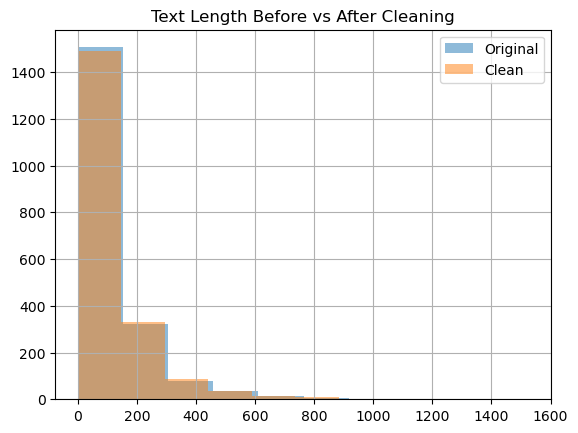

In [28]:
import matplotlib.pyplot as plt

train["original_length"].hist(alpha=0.5, label="Original")
train["clean_length"].hist(alpha=0.5, label="Clean")

plt.legend()
plt.title("Text Length Before vs After Cleaning")
plt.show()